# Assignment 6
**Author:** Lan Stare
**Date:** 2. 11. 2025

### (a)

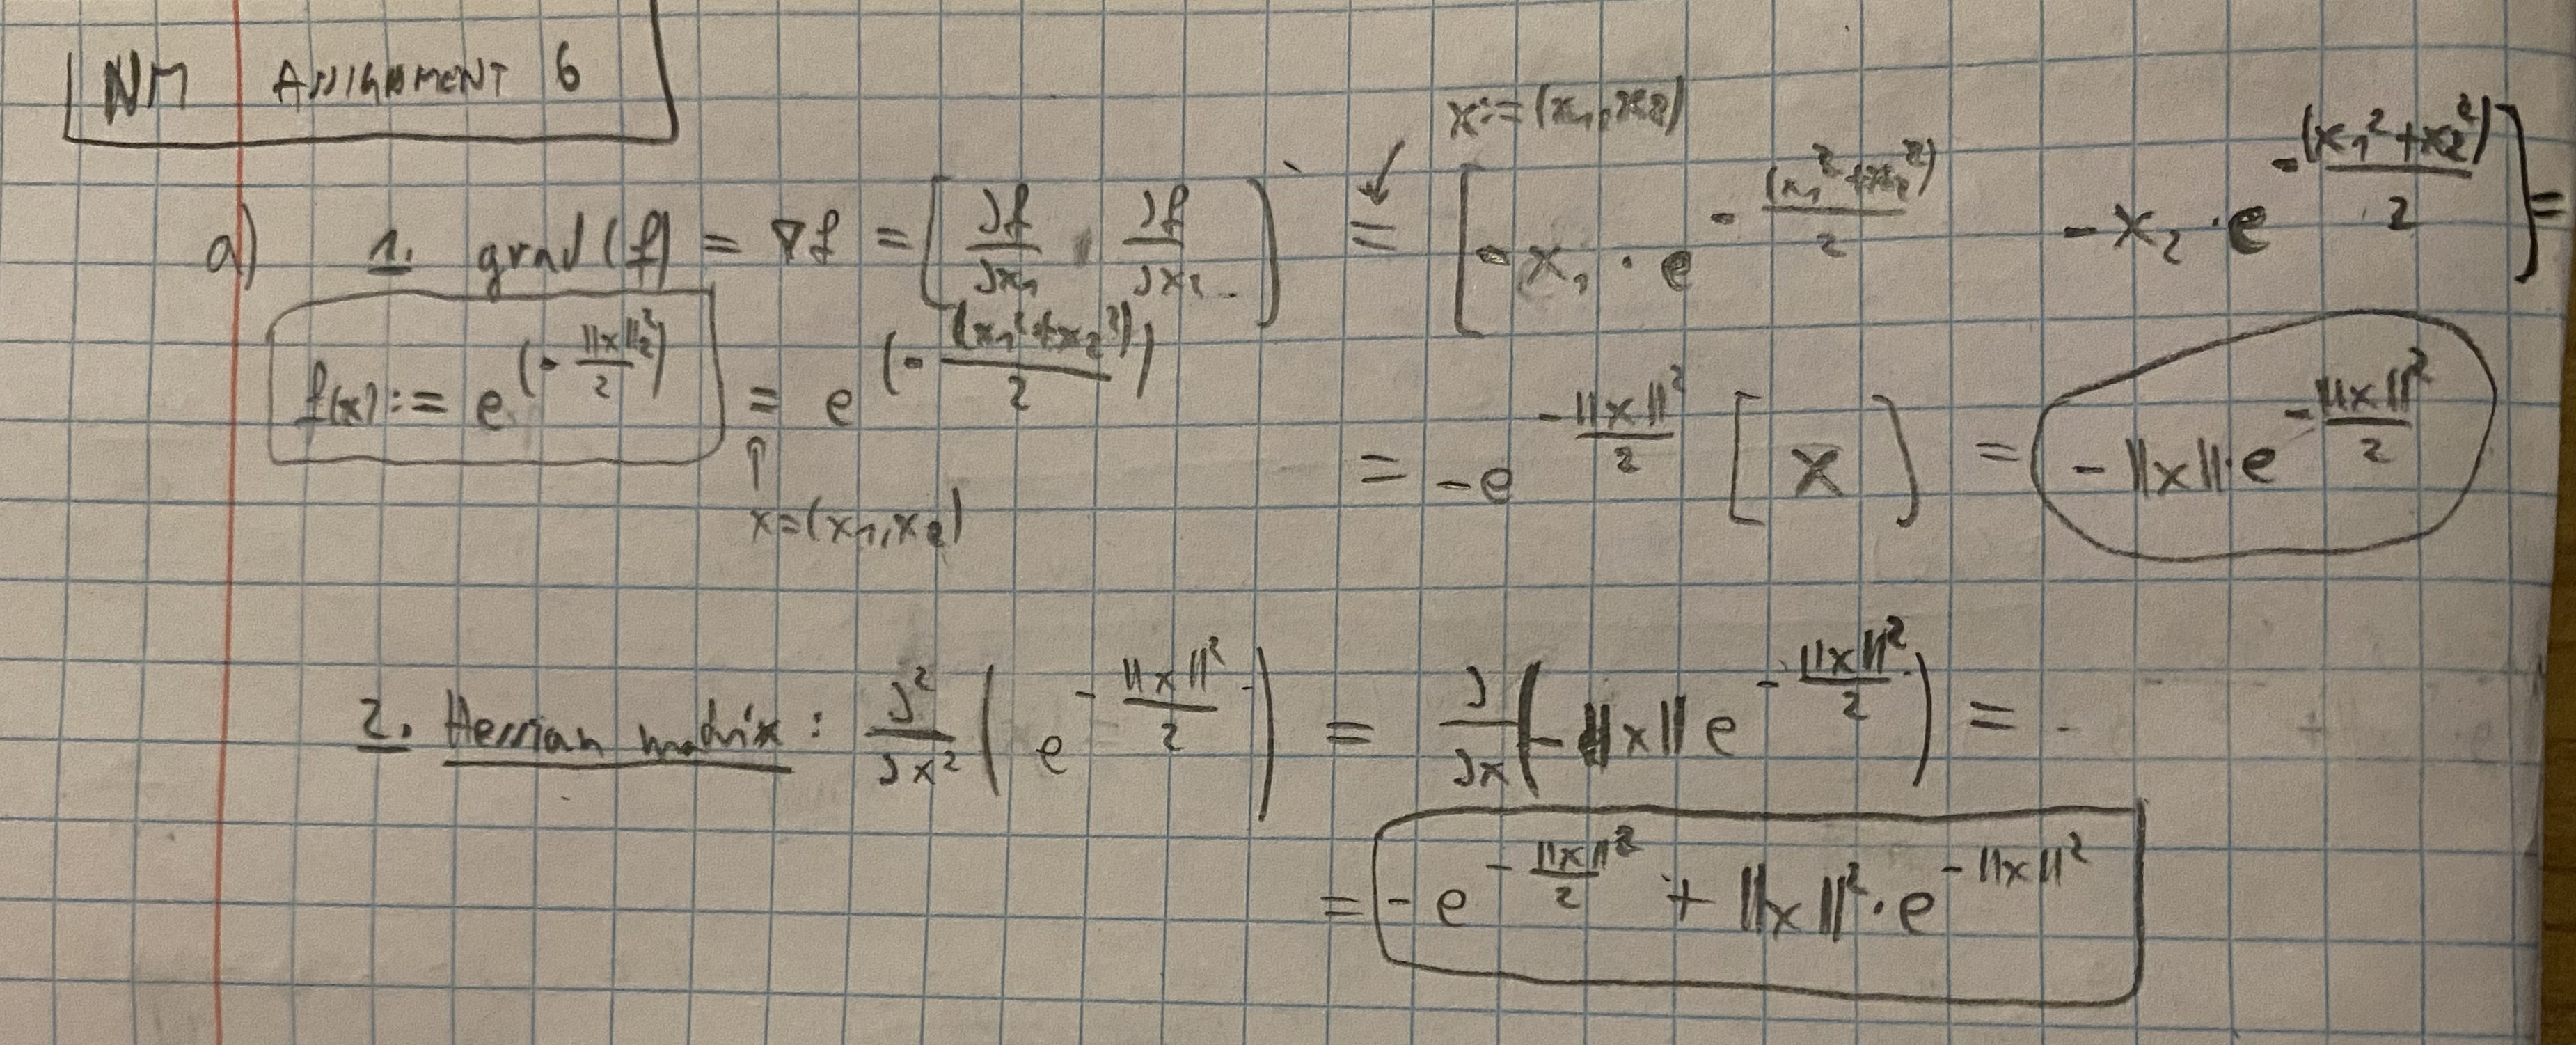

In [1]:
from IPython.display import Image, display

# Replace with your file path
image_path = "ex_a.jpeg"

display(Image(filename=image_path))

### (b)

In [ ]:
import numpy as np

def Newton(F, JF, x0, max_it, max_err):
    
    pass

### (c)

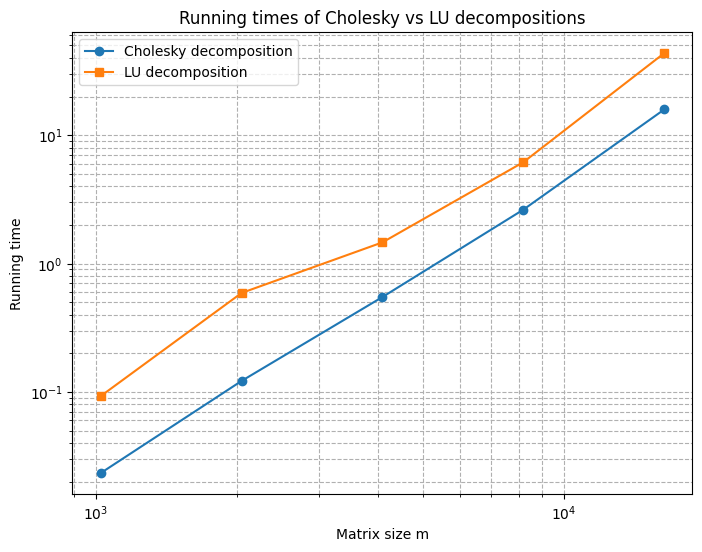


Results:
m =   1024:  Cholesky = 0.023300s,  LU = 0.092650s
m =   2048:  Cholesky = 0.121723s,  LU = 0.589784s
m =   4096:  Cholesky = 0.548650s,  LU = 1.462444s
m =   8192:  Cholesky = 2.629852s,  LU = 6.160318s
m =  16384:  Cholesky = 15.867758s,  LU = 43.570057s


In [1]:
from scipy import linalg
import numpy as np
import time
import matplotlib.pyplot as plt

def build_example_matrix(i):
    m = 2 ** i
    main_diag = 2 * np.ones(m)
    off_diag = -1 * np.ones(m - 1) #The elements beside the diagonal are -1
    matrix = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1) # this is how the np combines the diagonal matrices
    
    return matrix

# let-s buid the cholesky and LU decomp
def build_cholesky_and_LU(matrix):
    cholesky = linalg.cholesky(matrix)
    P, L, U = linalg.lu(matrix)
    return cholesky, (P, L, U)

i_values = range(10, 15)
m_values = [2 ** i for i in i_values]
times_cholesky = []
times_lu = []

for i, m in zip(i_values, m_values):
    A = build_example_matrix(i)
    # Measure Cholesky time
    start = time.time()
    linalg.cholesky(A) # this builds a cholesky decomposition
    end = time.time()
    times_cholesky.append(end - start)
    # Measure LU time
    start = time.time()
    linalg.lu(A) # this builds an LU decomposition
    end = time.time()
    times_lu.append(end - start)

# now we can start plotting
plt.figure(figsize=(8, 6))
plt.loglog(m_values, times_cholesky, 'o-', label='Cholesky decomposition')
plt.loglog(m_values, times_lu, 's-', label='LU decomposition')
plt.xlabel('Matrix size m')
plt.ylabel('Running time')
plt.title('Running times of Cholesky vs LU decompositions')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# this is so we can see the results
print("\nResults:")
for m, tc, tl in zip(m_values, times_cholesky, times_lu):
    print(f"m = {m:6d}:  Cholesky = {tc:.6f}s,  LU = {tl:.6f}s")

From the lectures we already know that the number of flops for the LU decomposition of m*m matrix is 2/3 m^3 and for the Cholesky decomposition about 1/3 m^3 flops. n the log–log plot of running times versus m, both curves should appear as roughly straight lines with a slope close to 3, reflecting the O(m^3) growth rate. The Cholesky curve is below the LU curve because of the smaller constant factor in its complexity (about 1/2 of LU’s cost).

### (d)